This notebook trains **Support Vector Regression (SVR)** models to predict taxi-trip demand in spatio-temporal resolution (spatial unit × time basket) using the prepared datasets in `data/2026_07_17_dataset/03`.

Three temporal resolutions are available (**1 h, 4 h, 1 d**) and two spatial layers (**census tract, community area**), each pre-split into **train / validation / test**.

### Approach (sequential model selection)
All 24 combinations (2 spatial × 3 temporal × 2 target settings × 2 encoding options) are trained once and the analysis then proceeds in four selection phases so that each decision builds on the previous one:

| Phase | Question | Configurations |
|---|---|---|
| Full grid | train every combination once | 2 spatial × 3 temporal × 2 target × 2 encoding |
| 1 : Spatial layer (1 h) | census tract vs community area | both normal target, weather features |
| 2 : Target encoding (1 h) | with vs without target encoding | both spatial layers |
| 3 : Target transform (1 h) | normal vs log1p | best spatial layer from Phase 1 |
| 4 : Temporal resolution | 1 h vs 4 h vs 1 d | best spatial + best target from Phase 3 |

The model family (LinearSVR -> RBF -> Polynomial) and all hyperparameters are selected with grid search on the validation set. Final performance is always reported on the held-out test set. The test set is never used to select a configuration.

## 0) Setup and configuration


In [39]:
# imports
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVR, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_DIR = "../data/2026_07_17_dataset/03"

# colours for plots (matplotlib named colours)
SPATIAL_COLORS = {"census_tract": "steelblue", "community_area": "seagreen"}
BIN_COLORS = {"1h": "steelblue", "4h": "darkorange", "1d": "mediumpurple"}

# print of the complete rows in tables
pl.Config.set_tbl_rows(-1)


polars.config.Config

# 1) Data loading
Loading of the Datasets prepared in 03_data_preparation


In [40]:
# census_tract
ct_1h_train = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1h_train.parquet")
ct_1h_val   = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1h_val.parquet")
ct_1h_test  = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1h_test.parquet")
ct_4h_train = pl.read_parquet(f"{DATA_DIR}/03_census_tract_4h_train.parquet")
ct_4h_val   = pl.read_parquet(f"{DATA_DIR}/03_census_tract_4h_val.parquet")
ct_4h_test  = pl.read_parquet(f"{DATA_DIR}/03_census_tract_4h_test.parquet")
ct_1d_train = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1d_train.parquet")
ct_1d_val   = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1d_val.parquet")
ct_1d_test  = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1d_test.parquet")
# community_area
ca_1h_train = pl.read_parquet(f"{DATA_DIR}/03_community_area_1h_train.parquet")
ca_1h_val   = pl.read_parquet(f"{DATA_DIR}/03_community_area_1h_val.parquet")
ca_1h_test  = pl.read_parquet(f"{DATA_DIR}/03_community_area_1h_test.parquet")
ca_4h_train = pl.read_parquet(f"{DATA_DIR}/03_community_area_4h_train.parquet")
ca_4h_val   = pl.read_parquet(f"{DATA_DIR}/03_community_area_4h_val.parquet")
ca_4h_test  = pl.read_parquet(f"{DATA_DIR}/03_community_area_4h_test.parquet")
ca_1d_train = pl.read_parquet(f"{DATA_DIR}/03_community_area_1d_train.parquet")
ca_1d_val   = pl.read_parquet(f"{DATA_DIR}/03_community_area_1d_val.parquet")
ca_1d_test  = pl.read_parquet(f"{DATA_DIR}/03_community_area_1d_test.parquet")

# quick overview of the two 1h datasets
for name, tr in [("census_tract_1h", ct_1h_train), ("community_area_1h", ca_1h_train)]:
    print(f"{name}: train={tr.shape[0]:,}  trip_count mean={tr['trip_count'].mean():.1f}")


census_tract_1h: train=6,762,388  trip_count mean=0.6
community_area_1h: train=1,100,854  trip_count mean=8.5


## 1.1) Target distribution
trip_count is right-skewed with a long tail. Most spatial-unit/time baskets have low counts while a few have very high demand. This skew motivates the log1p target transform tested in Phase 3.


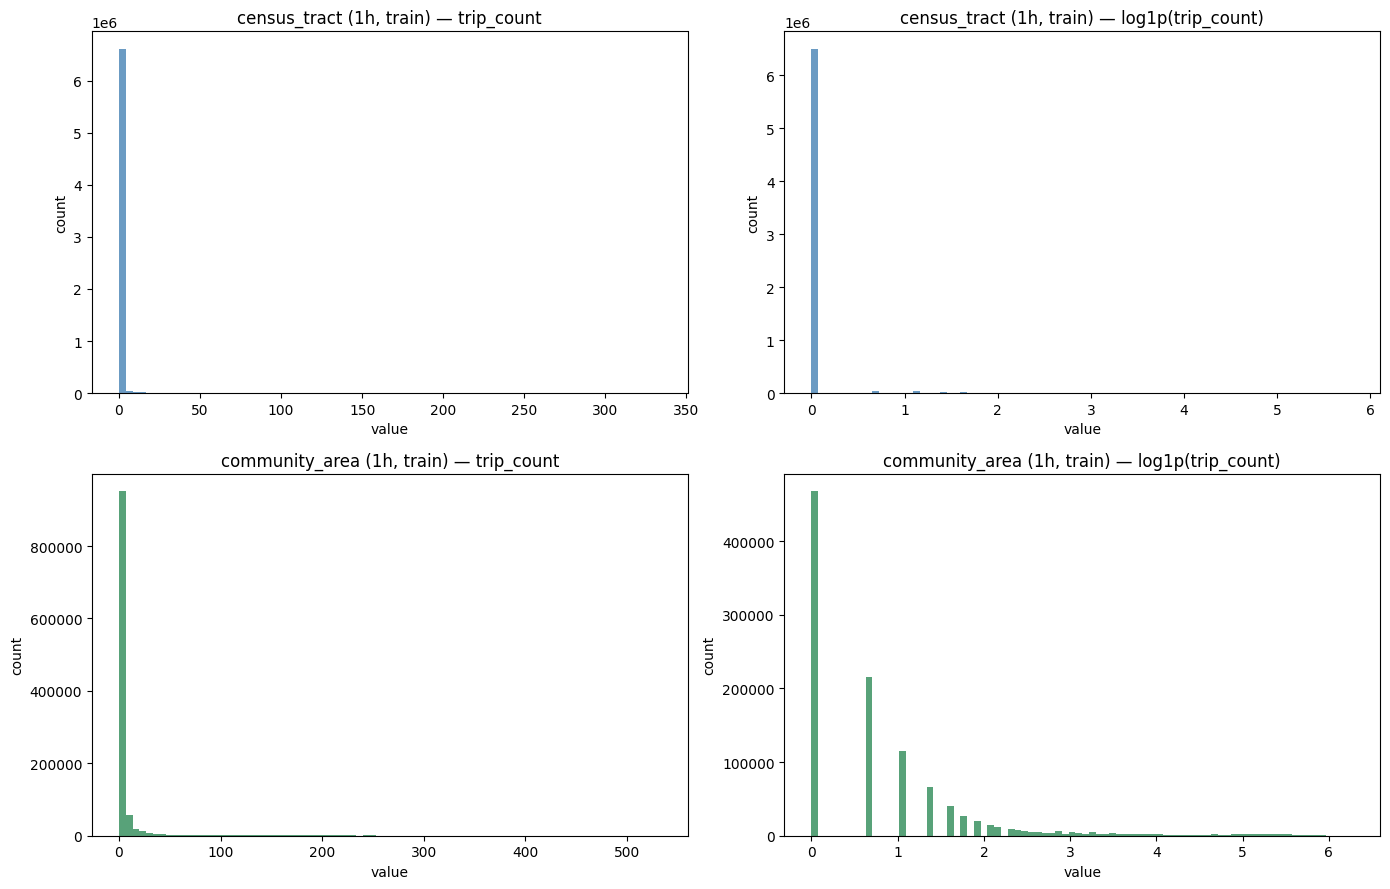

In [41]:
# right-skewed target motivates the log1p transform tested in Phase 3
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, (spatial, tr) in enumerate([("census_tract", ct_1h_train),
                                     ("community_area", ca_1h_train)]):
    vals = tr["trip_count"].to_numpy()
    axes[row, 0].hist(vals, bins=80, color=SPATIAL_COLORS[spatial], alpha=0.8)
    axes[row, 0].set_title(f"{spatial} (1h, train) — trip_count")
    axes[row, 1].hist(np.log1p(vals), bins=80, color=SPATIAL_COLORS[spatial], alpha=0.8)
    axes[row, 1].set_title(f"{spatial} (1h, train) — log1p(trip_count)")
    for ax in axes[row]:
        ax.set_xlabel("value"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

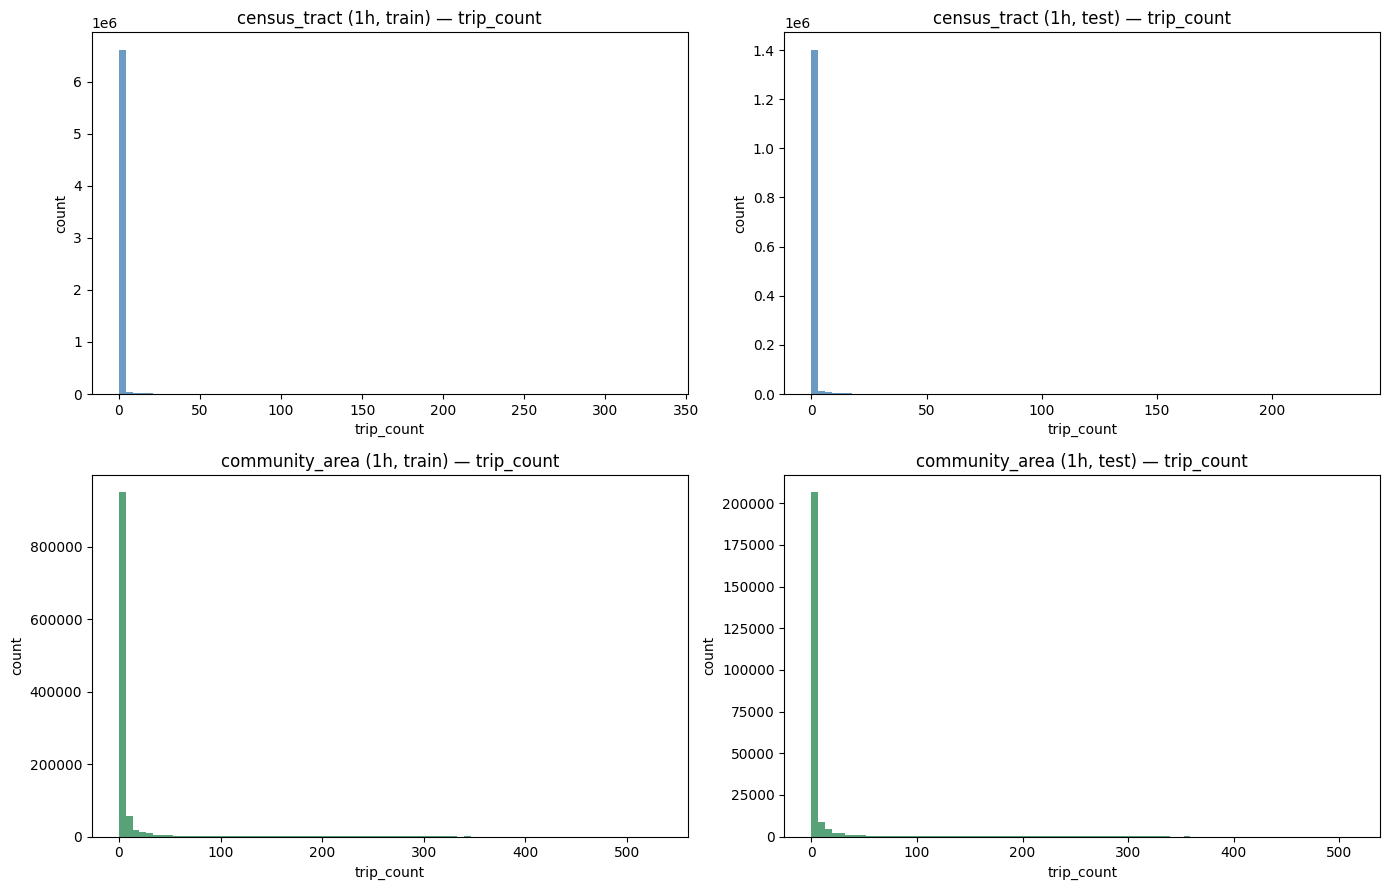

In [42]:
#| label: fig-svr-train-test-dist
#| fig-cap: "Distribution of trip counts in training and test set (community areas, 1h)."
# check: is the test distribution representative of training?
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, (spatial, tr, te) in enumerate([("census_tract", ct_1h_train, ct_1h_test),
                                         ("community_area", ca_1h_train, ca_1h_test)]):
    axes[row, 0].hist(tr["trip_count"].to_numpy(), bins=80, color=SPATIAL_COLORS[spatial], alpha=0.8)
    axes[row, 0].set_title(f"{spatial} (1h, train) — trip_count")
    axes[row, 1].hist(te["trip_count"].to_numpy(), bins=80, color=SPATIAL_COLORS[spatial], alpha=0.8)
    axes[row, 1].set_title(f"{spatial} (1h, test) — trip_count")
    for ax in axes[row]:
        ax.set_xlabel("trip_count"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()


# 2) Feature preparation
Feature preparation converts the raw dataset columns into the model's input matrix. Target Encoding which calculates the mean trip count per hourly bin per spatial resolution is included. Only done on train to avoid data leakage

For daily bins the hour_sin / hour_cos features are excluded (an hour-of-day signal is meaningless when every basket spans a full day).


In [43]:
# explicit feature columns (everything except the spatial ID and the target trip_count)
# centroid_lat / centroid_lon: spatial-unit centroids, lets the model learn geographic proximity (nearby units get similar predictions)
FEATURE_COLS = [
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "DayOfWeek_Friday", "DayOfWeek_Saturday", "DayOfWeek_Sunday",
    "DayOfWeek_Thursday", "DayOfWeek_Tuesday", "DayOfWeek_Wednesday",
    "BankHoliday", "CorporateHoliday", "CityHoliday", "StateHoliday",
    "rain", "strong_rain", "snow", "wind", "strong_wind",
    "temperature_c", "temperature_max_c", "temperature_min_c",
    "healthcare", "education", "amenity", "leisure",
    "shops", "public_services", "tourism", "nature",
    "centroid_lat", "centroid_lon",
]
# daily bins have no hour-of-day signal; drop hour_sin / hour_cos
FEATURE_COLS_1D = [c for c in FEATURE_COLS if c not in ("hour_sin", "hour_cos")]


def prepare_dataset(train_df, val_df, test_df, spatial_col,
                    bin_label="1h", target_encoding=True):
    feats = FEATURE_COLS_1D if bin_label == "1d" else FEATURE_COLS
    if target_encoding: # Calculate the spatial mean of the target variable
        spatial_mean = (train_df.group_by(spatial_col)
                        .agg(pl.col("trip_count").mean().alias("spatial_target_mean")))
        global_mean = train_df["trip_count"].mean() # Global mean serves as a fallback for new, unseen categories in Val/Test
        # Join the encodings to all splits and fill null values with the global mean
        # maintain_order keeps row alignment so y_pred can later be attached positionally
        train_df = train_df.join(spatial_mean, on=spatial_col, how="left", maintain_order="left").with_columns(
            pl.col("spatial_target_mean").fill_null(global_mean))
        val_df = val_df.join(spatial_mean, on=spatial_col, how="left", maintain_order="left").with_columns(
            pl.col("spatial_target_mean").fill_null(global_mean))
        test_df = test_df.join(spatial_mean, on=spatial_col, how="left", maintain_order="left").with_columns(
            pl.col("spatial_target_mean").fill_null(global_mean))
        feat_final = feats + ["spatial_target_mean"]
    else:
        feat_final = feats
    # Convert DataFrame splits into NumPy arrays for the ML model
    return {
        "X_train": train_df.select(feat_final).to_numpy(),
        "y_train": train_df["trip_count"].to_numpy().astype(float),
        "X_val":   val_df.select(feat_final).to_numpy(),
        "y_val":   val_df["trip_count"].to_numpy().astype(float),
        "X_test":  test_df.select(feat_final).to_numpy(),
        "y_test":  test_df["trip_count"].to_numpy().astype(float),
    }


## Validation strategy
The datasets arrive pre-split chronologically into train, validation and test (see notebook 03). Hyper-parameter tuning uses a PredefinedSplit so that every grid-search candidate is fit on the train fold and scored on the validation fold. Because kernel SVR scales approximately O(n²), grid search fits on a 20k-row train subsample and scores on a 20k-row validation subsample. The best configuration is then refit on a 50k-row train subsample and evaluated on the full test set. When log1p is used, predictions are inverse-transformed with expm1 before computing the error, so model selection always happens on the original scale.


# 3) Model training
Three SVR variants are trained, following the assignment's *“start without a kernel, then make it more complex”* instruction: LinearSVR (no kernel) → RBF → Polynomial. Each is tuned with grid search on the validation set; the best family is selected by validation RMSE, refit, and scored on the test set.
Two different iteration caps are used: LinearSVR is capped at max_iter=10_000 and the kernel SVR families (RBF, Polynomial) at max_iter=50_000. Without such a cap the solver runs until convergence with no upper bound, so some configurations ran indefinitely.
Subsampling is necessary because SVR scales approximately O(n²); the full training set would be intractable. Grid search therefore fits on a 20,000-row subsample and the best configuration is refit on 50,000 rows.
The custom scorer _rmse_original_scale applies expm1 to predictions before computing RMSE whenever log1p is active. This prevents the grid search from selecting a kernel that minimizes log-scale error but explodes after back-transformation.
Some kernel configurations hit the iteration cap and terminate before full convergence. This is an accepted trade-off given the O(n²) cost of kernel SVR at these subsample sizes. The printed `solver iterations used` line makes this visible per run.
The epsilon grid is scaled to the target range: for log1p targets, which live roughly in [0, 8], the epsilon candidates are tightened so that not every point sits inside the insensitive tube.
C and gamma are log-spaced around the sklearn defaults to span both under- and over-regularised regimes, epsilon is scaled to the target range (see the pipeline cell), and the polynomial degree is capped at 3 because higher degrees are numerically unstable on this feature set.

In [44]:
GRID_SAMPLE_SIZE = 20000      # train subsample for grid-search fitting
VAL_SAMPLE_SIZE  = 20000      # validation subsample for grid-search scoring
REFIT_SAMPLE_SIZE = 50000     # train subsample for final refit


def _subsample(X, y, n, rng):
    # daily bins have fewer rows than the sample sizes; return them unchanged
    if len(X) <= n:
        return X, y
    idx = rng.choice(len(X), size=n, replace=False)
    return X[idx], y[idx]


def _rmse_original_scale(estimator, X, y_log):
    # score log-target candidates on the original scale:
    # inverse-transform predictions first, then compute RMSE
    pred = np.expm1(estimator.predict(X))
    return -np.sqrt(np.mean((np.expm1(y_log) - pred) ** 2))


def run_svr_pipeline(data, log_target=False, tag=""):
    X_train, y_train = data["X_train"], data["y_train"]
    X_val,   y_val   = data["X_val"],   data["y_val"]
    X_test,  y_test  = data["X_test"],  data["y_test"]

    # log1p target transform (transform + inverse kept together in this function)
    if log_target:
        y_train = np.log1p(y_train)
        y_val   = np.log1p(y_val)

    # subsample train (fit) and validation (score) kernel SVR is O(n^2)
    rng = np.random.default_rng(21)
    X_sub, y_sub = _subsample(X_train, y_train, GRID_SAMPLE_SIZE, rng)
    X_val_s, y_val_s = _subsample(X_val, y_val, VAL_SAMPLE_SIZE, rng)
    print(f"  [{tag}] fit on {len(X_sub):,} train rows, score on {len(X_val_s):,} val rows")

    # PredefinedSplit: -1 = train fold (fit here), 0 = validation fold (scored)
    ps = PredefinedSplit(np.concatenate([np.full(len(X_sub), -1), np.zeros(len(X_val_s))]))
    # configs of the different kernel SVR models to grid-search over (with their hyperparameter grids)
    # epsilon must scale with the target: log1p targets live in ~[0, 8], so the
    # untransformed grid (0.1/1/10) would put every point inside the tube
    eps_grid = [0.01, 0.1, 0.5] if log_target else [0.1, 1, 10]
    configs = [
        ("LinearSVR",
         Pipeline([("scaler", StandardScaler()),
                   ("svr", LinearSVR(dual="auto", max_iter=10000, random_state=7))]),
         {"svr__C": [0.01, 0.1, 1, 10], "svr__epsilon": eps_grid}),
        ("RBF",
         Pipeline([("scaler", StandardScaler()),
                   ("svr", SVR(kernel="rbf", max_iter=50_000, cache_size=2000))]),
         {"svr__C": [0.1, 1, 10],
          "svr__gamma": ["scale", 0.01, 0.1, 1],
          "svr__epsilon": eps_grid}),
        ("Poly",
         Pipeline([("scaler", StandardScaler()),
                   ("svr", SVR(kernel="poly", max_iter=50_000, cache_size=2000))]),
         {"svr__C": [0.1, 1, 10],
          "svr__degree": [2, 3],
          "svr__coef0": [0, 1],
          "svr__epsilon": eps_grid}),
    ]
    # run grid-search for each kernel SVR model, score on the validation set, and refit the best model on a larger train subsample
    results = {}
    for model_name, pipe, grid in configs:
        if log_target:
            scoring = _rmse_original_scale
        else:
            scoring = "neg_mean_squared_error"
        gs = GridSearchCV(pipe, grid, cv=ps, scoring=scoring,
                          n_jobs=-1, refit=False)
        gs.fit(np.vstack([X_sub, X_val_s]), np.concatenate([y_sub, y_val_s]))
        if log_target:
            val_rmse = -gs.best_score_          # scorer already returns neg RMSE (original scale)
        else:
            val_rmse = np.sqrt(-gs.best_score_) # neg MSE to RMSE
        results[model_name] = {"val_rmse": val_rmse, "params": gs.best_params_, "pipe": pipe}
        print(f"    {model_name:10s} val RMSE={val_rmse:.4f}  {gs.best_params_}")

    # best model family by validation RMSE
    best_name = min(results, key=lambda k: results[k]["val_rmse"])
    best = results[best_name]
    model = best["pipe"].set_params(**best["params"])

    # refit on a larger train subsample
    X_refit, y_refit = _subsample(X_train, y_train, REFIT_SAMPLE_SIZE, rng)
    model.fit(X_refit, y_refit)

    print(f"    solver iterations used: {model.named_steps['svr'].n_iter_}")

    # predict on test (inverse-transform if log1p); metrics on original scale
    y_pred = model.predict(X_test)
    if log_target:
        y_pred = np.expm1(y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mask = y_test > 0
    mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
    print(f"    -> best: {best_name} | test R2={r2:.4f} RMSE={rmse:.4f} MAE={mae:.4f} MAPE={mape:.2f}%")

    return {"best_model": best_name, "best_params": results[best_name]["params"],
            "val_rmse": results[best_name]["val_rmse"],
            "test_mae": mae, "test_rmse": rmse, "test_r2": r2, "test_mape": mape,
            "y_pred": y_pred, "y_test": y_test,
            "all_val_rmse": {k: v["val_rmse"] for k, v in results.items()}}


# 4) Full grid on all 24 combinations

All 24 combinations (2 spatial layers × 3 temporal bins × 2 target settings × 2 encoding options) are trained once in the cell below and stored in grid_results. The four selection phases that follow no longer train anything. They just look up the relevant subset of `grid_results` and carry the winner forward.


In [45]:
GRID_DATA = {
    ("census_tract", "1h"):   (ct_1h_train, ct_1h_val, ct_1h_test),
    ("census_tract", "4h"):   (ct_4h_train, ct_4h_val, ct_4h_test),
    ("census_tract", "1d"):   (ct_1d_train, ct_1d_val, ct_1d_test),
    ("community_area", "1h"): (ca_1h_train, ca_1h_val, ca_1h_test),
    ("community_area", "4h"): (ca_4h_train, ca_4h_val, ca_4h_test),
    ("community_area", "1d"): (ca_1d_train, ca_1d_val, ca_1d_test),
}

grid_results = {}
for (spatial, bin_label), (tr, va, te) in GRID_DATA.items():
    for log_target in [False, True]:
        for te_flag in [True, False]:
            te_str = "" if te_flag else " (no TE)"
            tag = f"{spatial}_{bin_label}" + (" + log1p" if log_target else "") + te_str
            p = prepare_dataset(tr, va, te, spatial, bin_label,
                                target_encoding=te_flag)
            res = run_svr_pipeline(p, log_target=log_target, tag=tag)
            res.update({"spatial": spatial, "bin": bin_label,
                        "log_target": log_target, "tag": tag,
                        "target_encoding": te_flag})
            grid_results[tag] = res


  [census_tract_1h] fit on 20,000 train rows, score on 20,000 val rows
    LinearSVR  val RMSE=4.2203  {'svr__C': 10, 'svr__epsilon': 1}
    RBF        val RMSE=3.7874  {'svr__C': 10, 'svr__epsilon': 1, 'svr__gamma': 'scale'}
    Poly       val RMSE=3.0003  {'svr__C': 10, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 0.1}


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    solver iterations used: 50000
    -> best: Poly | test R2=0.6562 RMSE=3.2010 MAE=0.7265 MAPE=87.87%
  [census_tract_1h (no TE)] fit on 20,000 train rows, score on 20,000 val rows
    LinearSVR  val RMSE=5.5706  {'svr__C': 0.01, 'svr__epsilon': 1}
    RBF        val RMSE=5.0620  {'svr__C': 10, 'svr__epsilon': 1, 'svr__gamma': 'scale'}
    Poly       val RMSE=5.0286  {'svr__C': 10, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 1}


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    solver iterations used: 50000
    -> best: Poly | test R2=0.2205 RMSE=4.8203 MAE=0.9759 MAPE=83.18%
  [census_tract_1h + log1p] fit on 20,000 train rows, score on 20,000 val rows
    LinearSVR  val RMSE=4.4895  {'svr__C': 0.01, 'svr__epsilon': 0.5}
    RBF        val RMSE=3.6143  {'svr__C': 1, 'svr__epsilon': 0.01, 'svr__gamma': 0.01}
    Poly       val RMSE=4.2677  {'svr__C': 0.1, 'svr__coef0': 0, 'svr__degree': 2, 'svr__epsilon': 0.01}


...

    solver iterations used: 50000
    -> best: Poly | test R2=0.9299 RMSE=176.3862 MAE=45.8741 MAPE=110.72%
  [community_area_1d + log1p (no TE)] fit on 20,000 train rows, score on 9,840 val rows
    LinearSVR  val RMSE=472.4839  {'svr__C': 10, 'svr__epsilon': 0.1}
    RBF        val RMSE=206.8770  {'svr__C': 10, 'svr__epsilon': 0.01, 'svr__gamma': 0.01}


c:\Users\Kusha\miniconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


    Poly       val RMSE=173.5526  {'svr__C': 1, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 0.01}


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    solver iterations used: 50000
    -> best: Poly | test R2=0.6641 RMSE=386.0073 MAE=79.1942 MAPE=114.30%


# 5) Phase 1  Spatial layer comparison (1 h)
Both spatial layers are compared at 1h resolution with target encoding and without log1p. The better layer (by validation RMSE) is carried forward. Many tracts only see a handful of trips per time window, which makes their predictions noisy, while the coarser layer aggregates more trips per unit.


In [46]:
phase_spatial = {"census_tract":   grid_results["census_tract_1h"],
          "community_area": grid_results["community_area_1h"]}
# selection on validation RMSE; test metrics are reported but never used to decide
BEST_SPATIAL = min(phase_spatial, key=lambda k: phase_spatial[k]["val_rmse"])
print(f">> Best spatial layer (1h): {BEST_SPATIAL} "
      f"(val RMSE={phase_spatial[BEST_SPATIAL]['val_rmse']:.4f}, "
      f"test R2={phase_spatial[BEST_SPATIAL]['test_r2']:.4f})")


>> Best spatial layer (1h): census_tract (val RMSE=3.0003, test R2=0.6562)


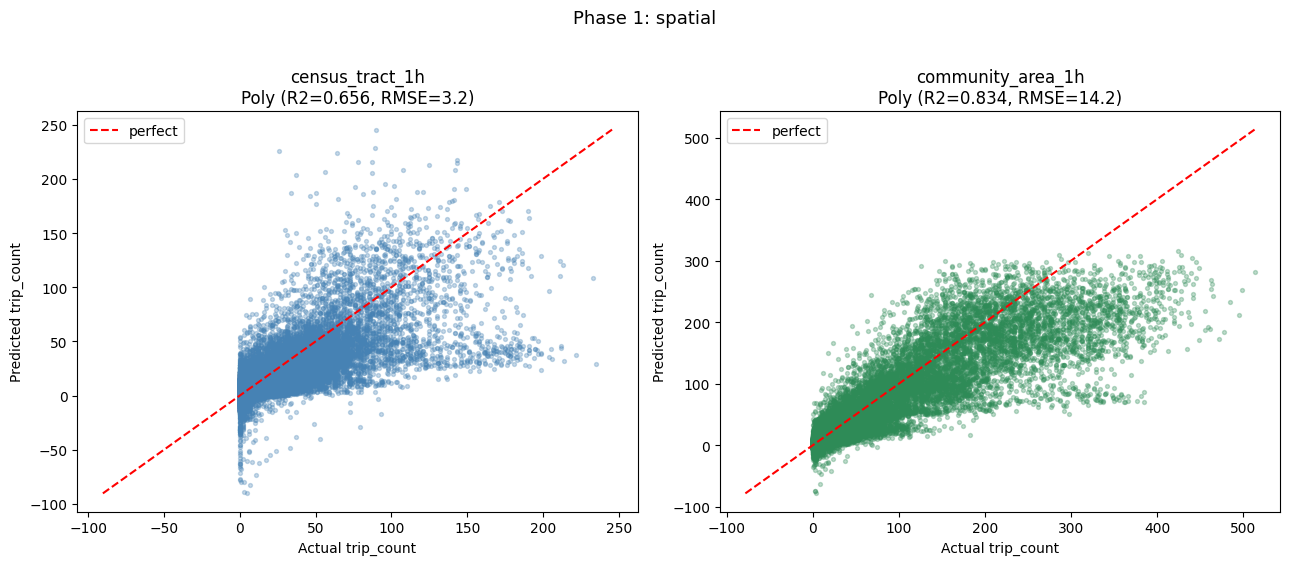

In [47]:
title, d = "Phase 1: spatial", phase_spatial
n = len(d)
fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 5.5), squeeze=False)
for ax, (k, res) in zip(axes[0], d.items()):
    yt, yp = res["y_test"], res["y_pred"]
    ax.scatter(yt, yp, s=8, alpha=0.3, color=SPATIAL_COLORS[res["spatial"]])
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="perfect")
    ax.set_xlabel("Actual trip_count"); ax.set_ylabel("Predicted trip_count")
    ax.set_title(f"{res['tag']}\n{res['best_model']} (R2={res['test_r2']:.3f}, RMSE={res['test_rmse']:.1f})")
    ax.legend()
fig.suptitle(title, y=1.02, fontsize=13)
plt.tight_layout();
plt.show()


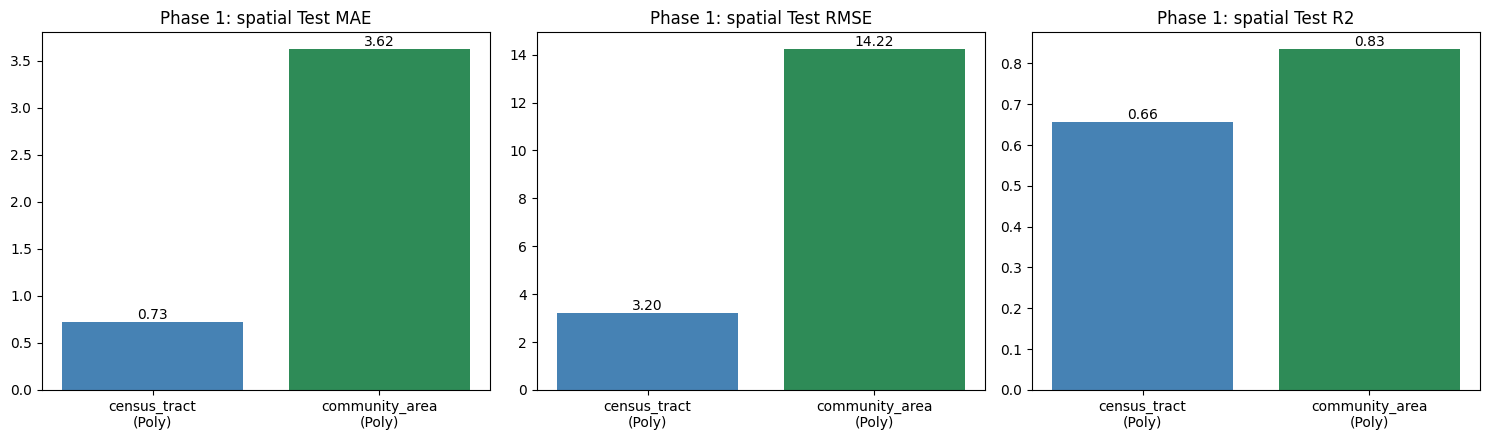

In [48]:
def metric_bars(results_dict, title, colors):
    metrics = ["test_mae", "test_rmse", "test_r2"]
    labels  = ["MAE", "RMSE", "R2"]
    names = list(results_dict.keys())
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, m, lab in zip(axes, metrics, labels):
        vals = [results_dict[n][m] for n in names]
        bar_labels = [f"{k}\n({v['best_model']})" for k, v in results_dict.items()]
        bars = ax.bar(bar_labels, vals, color=[colors.get(n, "steelblue") for n in names])
        ax.set_title(f"{title} Test {lab}")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{v:.2f}", ha="center", va="bottom")
    plt.tight_layout(); plt.show()

metric_bars(phase_spatial, "Phase 1: spatial",
            {k: SPATIAL_COLORS[v["spatial"]] for k, v in phase_spatial.items()})


# 6) Phase 2 Target encoding comparison (1 h)
Target encoding puts another column into the features. This column aggregates the average trips per decided bin in that spatial area during the whole training window. With this, the model understands if this area is a high frequency area or not. This was done at the 1h layer without log1p across both spatial layers since there is a difference important to look at.

Another idea would be to use dummy encoding for each spatial area which we rejected because that would lead to 448 more columns leading to the necessity of a lot more computational power.
The encoding also respects the assignment constraint, since it doesn’t use recent demand but instead a locations specific trait. The difference can be seen especially in census tracts. 
The target-encoding decision is made on validation RMSE and carried into the following phases.


In [49]:
phase_te = {
    "census_tract + TE":      grid_results["census_tract_1h"],
    "census_tract (no TE)":   grid_results["census_tract_1h (no TE)"],
    "community_area + TE":    grid_results["community_area_1h"],
    "community_area (no TE)": grid_results["community_area_1h (no TE)"],
}
for k, r in phase_te.items():
    print(f"{k:28s} R2={r['test_r2']:.4f}  MAPE={r['test_mape']:.1f}%")
# carry the TE setting forward explicitly instead of implicitly assuming it
BEST_TE = min(phase_te, key=lambda k: phase_te[k]["val_rmse"])
print(f">> Best target-encoding setting (1h): {BEST_TE}")


census_tract + TE            R2=0.6562  MAPE=87.9%
census_tract (no TE)         R2=0.2205  MAPE=83.2%
community_area + TE          R2=0.8343  MAPE=75.2%
community_area (no TE)       R2=0.8287  MAPE=195.7%
>> Best target-encoding setting (1h): census_tract + TE


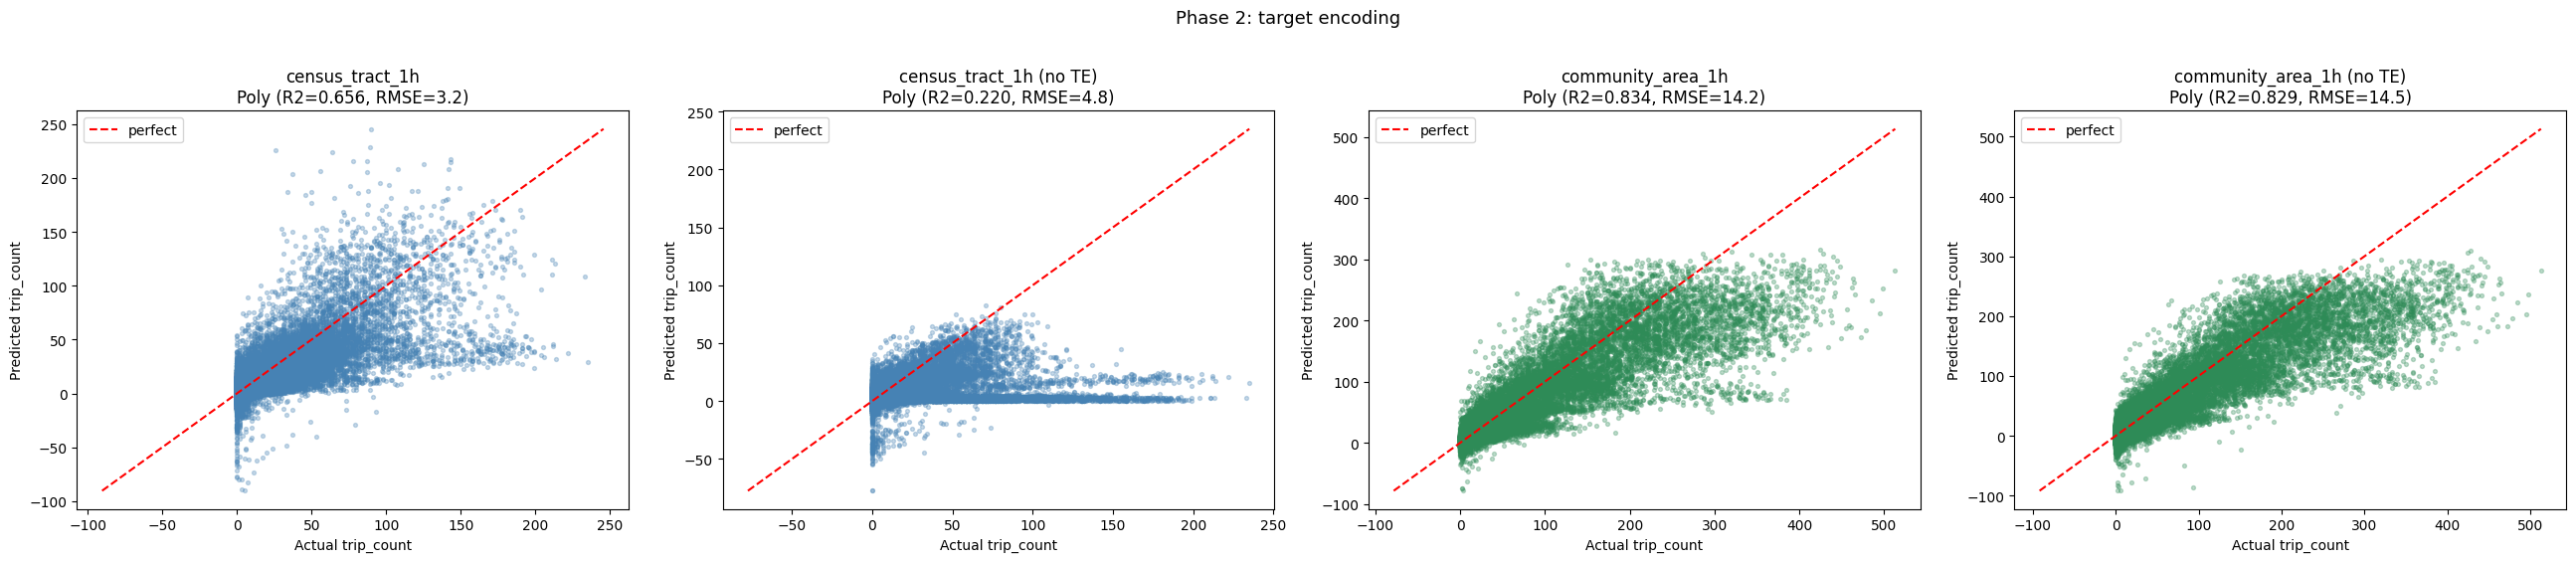

In [50]:
title, d = "Phase 2: target encoding", phase_te
n = len(d)
fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 5.5), squeeze=False)
for ax, (k, res) in zip(axes[0], d.items()):
    yt, yp = res["y_test"], res["y_pred"]
    ax.scatter(yt, yp, s=8, alpha=0.3, color=SPATIAL_COLORS[res["spatial"]])
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="perfect")
    ax.set_xlabel("Actual trip_count"); ax.set_ylabel("Predicted trip_count")
    ax.set_title(f"{res['tag']}\n{res['best_model']} (R2={res['test_r2']:.3f}, RMSE={res['test_rmse']:.1f})")
    ax.legend()
fig.suptitle(title, y=1.02, fontsize=13)
plt.tight_layout();
plt.show()


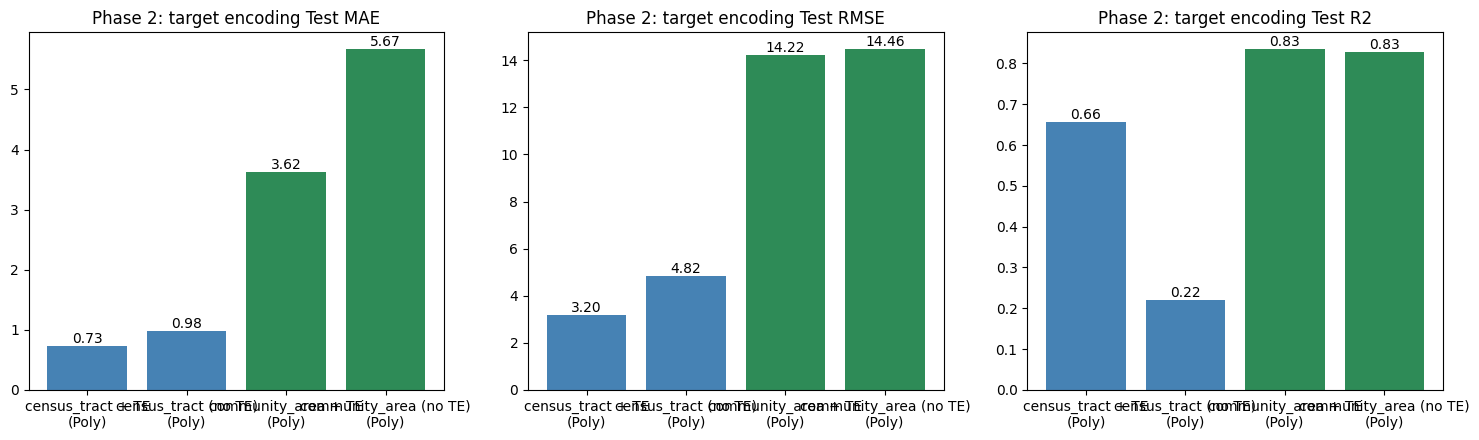

In [51]:
metric_bars(phase_te, "Phase 2: target encoding",
            {k: SPATIAL_COLORS[v["spatial"]] for k, v in phase_te.items()})


# 7) Phase 3 Target transform comparison (1 h)
Compares the untransformed target against log1p, on community areas with target encoding. Trip counts are strongly right skewed, so a few high demand trips dominate the squared error. We also added a custom RMSE scorer that back-transforms predictions with expm1 before computing error on the original scale. This was done to avoid selecting a kernel that looks strong on the log scale but fails after back transformation.


In [52]:
phase_target = {"normal": grid_results[f"{BEST_SPATIAL}_1h"],
          "log1p":  grid_results[f"{BEST_SPATIAL}_1h + log1p"]}
BEST_TARGET = min(phase_target, key=lambda k: phase_target[k]["val_rmse"])
print(f">> Best target setting (1h): {BEST_TARGET} "
      f"(val RMSE={phase_target[BEST_TARGET]['val_rmse']:.4f}, "
      f"test R2={phase_target[BEST_TARGET]['test_r2']:.4f})")


>> Best target setting (1h): normal (val RMSE=3.0003, test R2=0.6562)


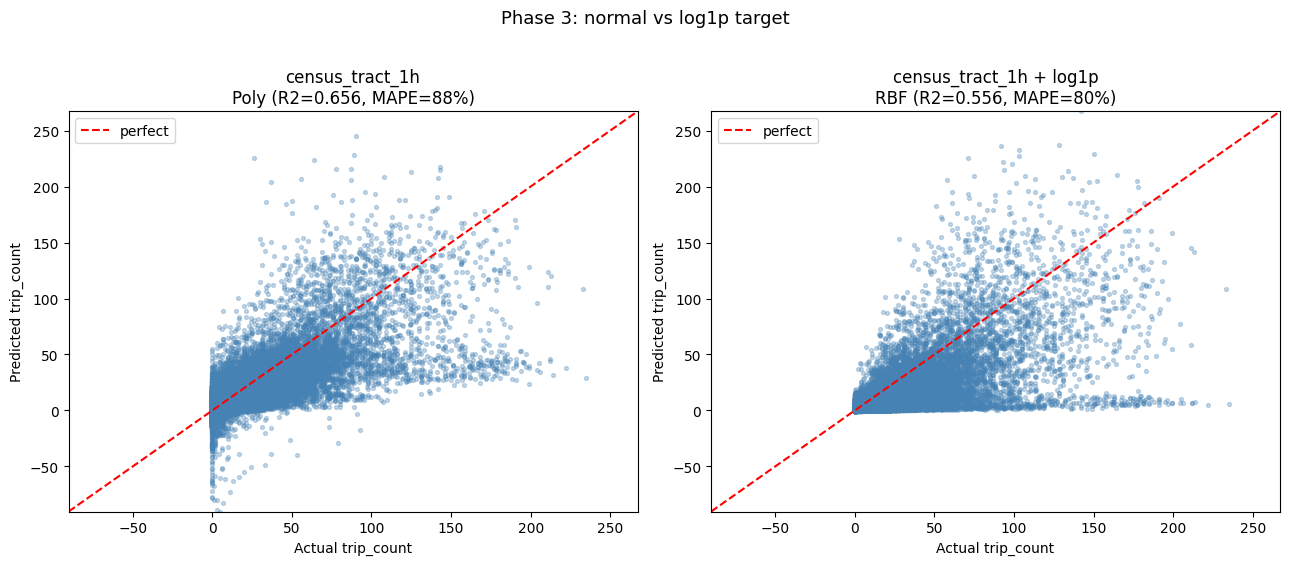

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
all_vals = np.concatenate([phase_target["normal"]["y_test"], phase_target["normal"]["y_pred"],
                           phase_target["log1p"]["y_test"],  phase_target["log1p"]["y_pred"]])
lims = [all_vals.min(), all_vals.max()]
for ax, key in zip(axes, ["normal", "log1p"]):
    res = phase_target[key]
    yt, yp = res["y_test"], res["y_pred"]
    ax.scatter(yt, yp, s=8, alpha=0.3, color=SPATIAL_COLORS[res["spatial"]])
    ax.plot(lims, lims, "r--", lw=1.5, label="perfect")
    ax.set_xlabel("Actual trip_count"); ax.set_ylabel("Predicted trip_count")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f"{res['tag']}\n{res['best_model']} "
                 f"(R2={res['test_r2']:.3f}, MAPE={res['test_mape']:.0f}%)")
    ax.legend()
fig.suptitle("Phase 3: normal vs log1p target", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()


# 8) Phase 4 Temporal resolution comparison
Final phase compares the three temporal resolutions of 1h, 4h and 1d, on the best spatial layer and the best target setting carried over from the previous phases.


In [54]:
suffix = " + log1p" if BEST_TARGET == "log1p" else ""
phase_temporal = {"1h": grid_results[f"{BEST_SPATIAL}_1h{suffix}"],
          "4h": grid_results[f"{BEST_SPATIAL}_4h{suffix}"],
          "1d": grid_results[f"{BEST_SPATIAL}_1d{suffix}"]}


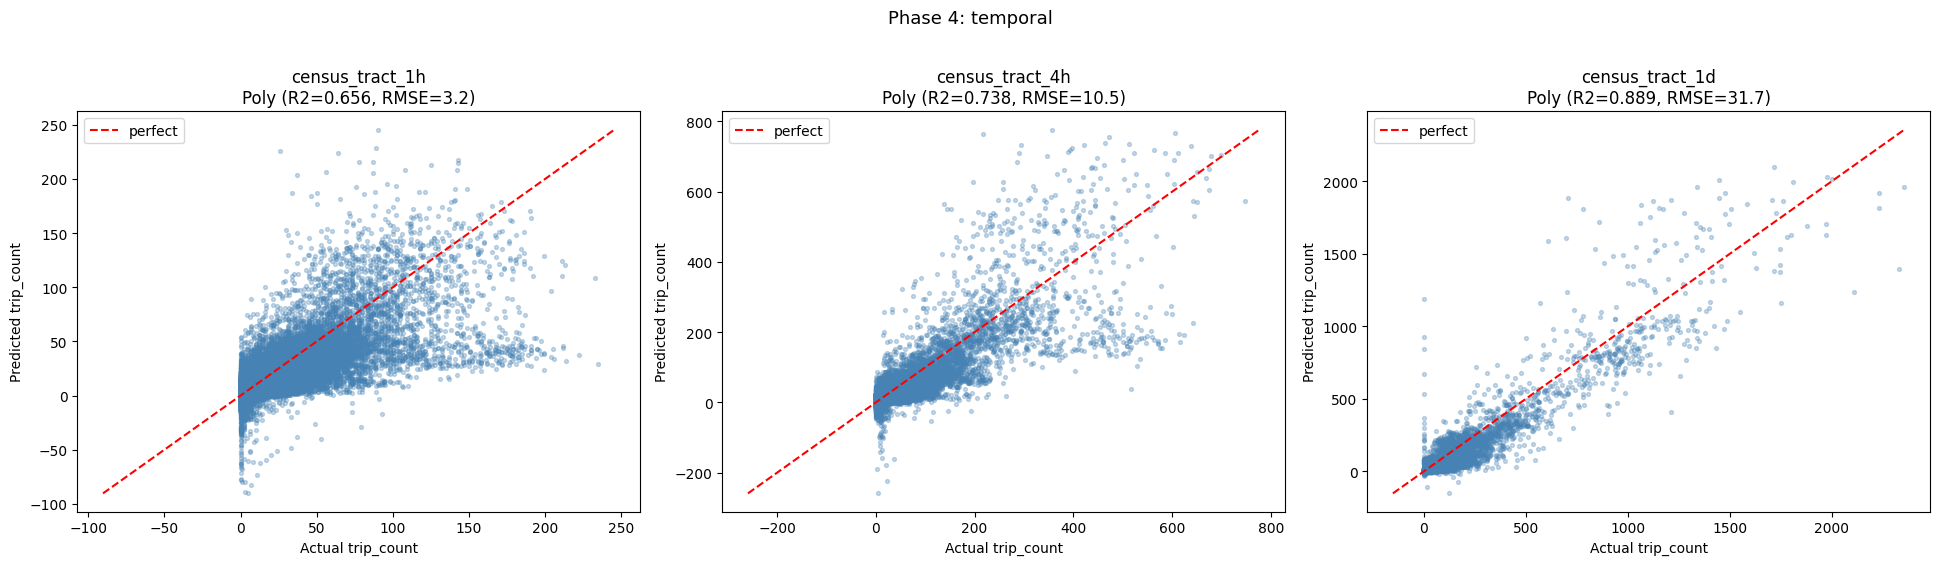

In [55]:
title, d = "Phase 4: temporal", phase_temporal
n = len(d)
fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 5.5), squeeze=False)
for ax, (k, res) in zip(axes[0], d.items()):
    yt, yp = res["y_test"], res["y_pred"]
    ax.scatter(yt, yp, s=8, alpha=0.3, color=SPATIAL_COLORS[res["spatial"]])
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="perfect")
    ax.set_xlabel("Actual trip_count"); ax.set_ylabel("Predicted trip_count")
    ax.set_title(f"{res['tag']}\n{res['best_model']} (R2={res['test_r2']:.3f}, RMSE={res['test_rmse']:.1f})")
    ax.legend()
fig.suptitle(title, y=1.02, fontsize=13)
plt.tight_layout();
plt.show()


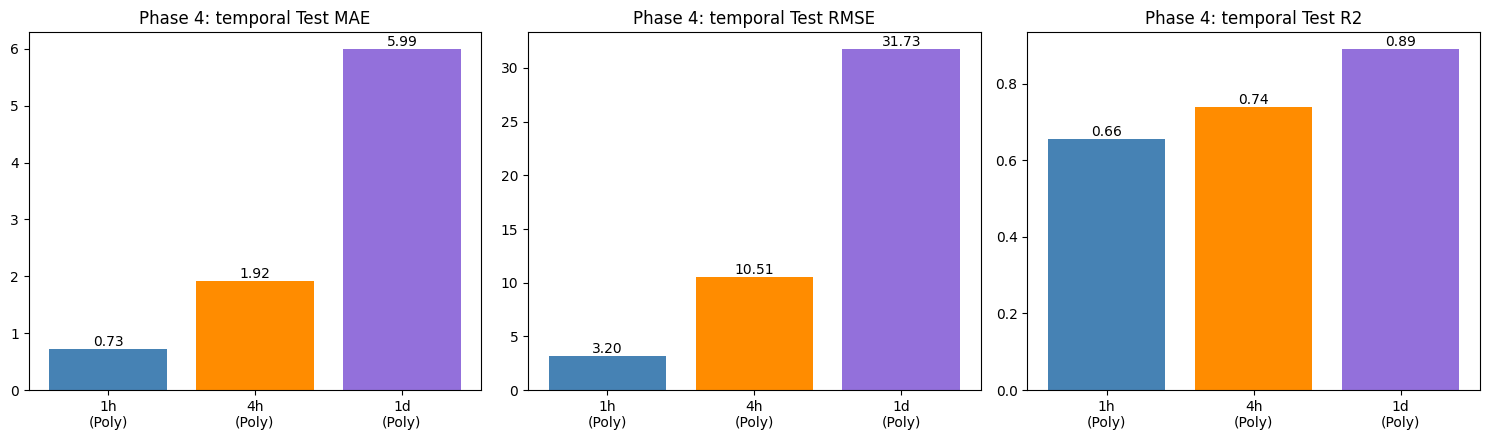

In [56]:
metric_bars(phase_temporal, "Phase 4: temporal", BIN_COLORS)


# 9) Results consolidated comparison
The table below collects every approach evaluated across the three phases. Each row is one full pipeline run (LinearSVR -> RBF -> Poly tuned on the validation set best family refit and scored on the test set).


In [57]:
#| label: tbl-svr-phases
#| tbl-cap: "SVR results across four controlled comparison phases."
def _row(res, phase):
    return {
        "Phase": phase,
        "Configuration": res["tag"],
        "Spatial": res["spatial"],
        "Bin": res["bin"],
        "Target": "log1p" if res["log_target"] else "normal",
        "Target Enc.": "yes" if res.get("target_encoding", True) else "no",
        "Best kernel": res["best_model"],
        "Val RMSE": round(res["val_rmse"], 4),
        "Test MAE": round(res["test_mae"], 4),
        "Test RMSE": round(res["test_rmse"], 4),
        "Test R2": round(res["test_r2"], 4),
        "Test MAPE": round(res["test_mape"], 2),
    }

rows = [_row(phase_spatial["census_tract"], "1: spatial"),
        _row(phase_spatial["community_area"], "1: spatial"),
        _row(phase_te["census_tract (no TE)"], "2: target encoding"),
        _row(phase_te["community_area (no TE)"], "2: target encoding"),
        _row(phase_target["normal"], "3: target transform"),
        _row(phase_target["log1p"],  "3: target transform")]
rows += [_row(phase_temporal[b], "4: temporal") for b in ["1h", "4h", "1d"]]

display(pl.DataFrame(rows))
print(f"\nSelected: spatial={BEST_SPATIAL} | target={BEST_TARGET}")


Phase,Configuration,Spatial,Bin,Target,Target Enc.,Best kernel,Val RMSE,Test MAE,Test RMSE,Test R2,Test MAPE
str,str,str,str,str,str,str,f64,f64,f64,f64,f64
"""1: spatial""","""census_tract_1h""","""census_tract""","""1h""","""normal""","""yes""","""Poly""",3.0003,0.7265,3.201,0.6562,87.87
"""1: spatial""","""community_area_1h""","""community_area""","""1h""","""normal""","""yes""","""Poly""",15.1075,3.6217,14.2237,0.8343,75.18
"""2: target encoding""","""census_tract_1h (no TE)""","""census_tract""","""1h""","""normal""","""no""","""Poly""",5.0286,0.9759,4.8203,0.2205,83.18
"""2: target encoding""","""community_area_1h (no TE)""","""community_area""","""1h""","""normal""","""no""","""Poly""",15.9775,5.6668,14.4618,0.8287,195.67
"""3: target transform""","""census_tract_1h""","""census_tract""","""1h""","""normal""","""yes""","""Poly""",3.0003,0.7265,3.201,0.6562,87.87
"""3: target transform""","""census_tract_1h + log1p""","""census_tract""","""1h""","""log1p""","""yes""","""RBF""",3.6143,0.4202,3.6388,0.5558,80.06
"""4: temporal""","""census_tract_1h""","""census_tract""","""1h""","""normal""","""yes""","""Poly""",3.0003,0.7265,3.201,0.6562,87.87
"""4: temporal""","""census_tract_4h""","""census_tract""","""4h""","""normal""","""yes""","""Poly""",11.9991,1.9221,10.5098,0.7384,105.34
"""4: temporal""","""census_tract_1d""","""census_tract""","""1d""","""normal""","""yes""","""Poly""",42.0058,5.9917,31.731,0.8891,104.32



Selected: spatial=census_tract | target=normal


## All metrics across configurations
The phase tables above show only the best kernel per configuration. This section computes a full set of regression metrics (R², MAE, RMSE, MedAE, normalized MAE, MAPE) across all 24 configurations for a complete overview. Because raw MAE is scale-dependent (daily windows hold roughly 24 times more trips than hourly ones), normalized MAE (MAE divided by mean demand) is used for cross-resolution comparison.
MAPE is computed only over test baskets with `trip_count > 0`, since the relative error is undefined for empty baskets; the share of such baskets should therefore be read alongside it.

In [76]:
#| label: tbl-svr-full-grid
#| tbl-cap: "Full regression metrics across all 24 SVR configurations."
# overview of regression metrics across all 24 configurations.
# some log-target configurations show large negative R2: the polynomial kernel extrapolates explosively once predictions are back-transformed with expm1.
# the custom original-scale scorer is what keeps this from affecting selection in the configurations that matter for the phase comparisons.
metrics_rows = []
for tag, res in grid_results.items():
    yt = res["y_test"]
    metrics_rows.append({
        "Config": tag,
        "Kernel": res["best_model"],
        "Spatial": res["spatial"],
        "Bin": res["bin"],
        "Log": "yes" if res["log_target"] else "no",
        "TE": "yes" if res.get("target_encoding", True) else "no",
        "R2": round(res["test_r2"], 4),
        "MAE": round(res["test_mae"], 2),
        "RMSE": round(res["test_rmse"], 2),
        "RMAE": round(res["test_mae"] / np.mean(yt), 4),
        "MAPE%": round(res["test_mape"], 1),
    })
all_metrics = pl.DataFrame(metrics_rows)
summary = all_metrics.select([
    "Config", "Kernel", "R2", "RMAE"
]).sort("R2", descending=True)

print(summary.to_pandas().to_markdown(index=False, floatfmt=".4f"))

| Config                            | Kernel   |        R2 |   RMAE |
|:----------------------------------|:---------|----------:|-------:|
| community_area_1d                 | Poly     |    0.9332 | 0.2305 |
| community_area_1d (no TE)         | Poly     |    0.9326 | 0.2529 |
| community_area_1d + log1p         | Poly     |    0.9299 | 0.2313 |
| community_area_4h + log1p (no TE) | RBF      |    0.9122 | 0.2977 |
| community_area_4h + log1p         | RBF      |    0.8929 | 0.3207 |
| census_tract_1d                   | Poly     |    0.8891 | 0.4049 |
| community_area_4h                 | Poly     |    0.8795 | 0.3901 |
| community_area_4h (no TE)         | Poly     |    0.8656 | 0.4319 |
| community_area_1h                 | Poly     |    0.8343 | 0.4356 |
| community_area_1h (no TE)         | Poly     |    0.8287 | 0.6815 |
| community_area_1h + log1p         | RBF      |    0.8286 | 0.4005 |
| community_area_1h + log1p (no TE) | RBF      |    0.8285 | 0.4083 |
| census_tract_1d + 

The accuracy report adds another analytical aspect for comparison. How often is the prediction within a given tolerance of the actual count? This answers questions like "in what share of 4h windows does the model get the demand right within ±5 trips?" Absolute tolerances (exact match, ±1, ±2, ±5 trips) are useful for low-demand areas, while relative tolerances (±10%, ±20%) are more meaningful for high-demand areas where being off by 5 trips may still be operationally acceptable.

In [59]:
#| label: tbl-svr-accuracy
#| tbl-cap: "SVR prediction accuracy under absolute and relative tolerances."
def accuracy_report(y_true, y_pred, abs_tolerances=(0, 1, 2, 5), rel_tolerances=(0.10, 0.20)):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    # Round predictions since trip counts are discrete integers
    abs_err = np.abs(np.round(y_pred) - y_true)

    report = {"n_test": len(y_true)}
    for tol in abs_tolerances:
        label = "exact_match" if tol == 0 else f"within_{tol}_trips"
        report[label] = float(np.mean(abs_err <= tol))
    # # Filter out zero actuals to prevent division by zero in relative error calculation
    nonzero = y_true != 0
    rel_err = np.abs(y_pred[nonzero] - y_true[nonzero]) / y_true[nonzero]
    for tol in rel_tolerances:
        report[f"within_{int(tol * 100)}pct"] = float(np.mean(rel_err <= tol))
    return report

accuracy_rows = []
for tag, res in grid_results.items():
    row = {"experiment": tag}
    row.update(accuracy_report(res["y_test"], res["y_pred"]))
    accuracy_rows.append(row)

accuracy_df = pl.DataFrame(accuracy_rows)
# show percentages rounded, sorted by the +/-5 trips hit rate
display(accuracy_df.with_columns([
    (pl.col(c) * 100).round(1)
    for c in accuracy_df.columns if c not in ("experiment", "n_test")
]).sort("within_5_trips", descending=True))


experiment,n_test,exact_match,within_1_trips,within_2_trips,within_5_trips,within_10pct,within_20pct
str,i64,f64,f64,f64,f64,f64,f64
"""census_tract_1h""",1449082,71.5,94.9,96.6,98.2,6.1,12.7
"""census_tract_1h + log1p""",1449082,95.3,96.3,97.0,98.1,3.2,6.6
"""census_tract_1h + log1p (no TE…",1449082,86.0,96.4,97.1,98.1,2.8,6.0
"""census_tract_1h (no TE)""",1449082,58.5,92.7,96.1,98.0,4.0,8.2
"""census_tract_4h""",362341,26.7,91.0,93.6,96.0,6.1,12.6
"""census_tract_4h + log1p""",362341,92.3,93.6,94.5,96.0,3.6,7.1
"""census_tract_4h + log1p (no TE…",362341,92.7,93.8,94.7,96.0,2.3,4.4
"""census_tract_1d + log1p (no TE…",60449,72.3,88.9,90.4,92.1,2.7,6.0
"""census_tract_1d""",60449,28.9,80.6,87.4,92.0,5.6,12.6


Plot with all configurations ordered by R². One log-target configuration produce strongly negative R².

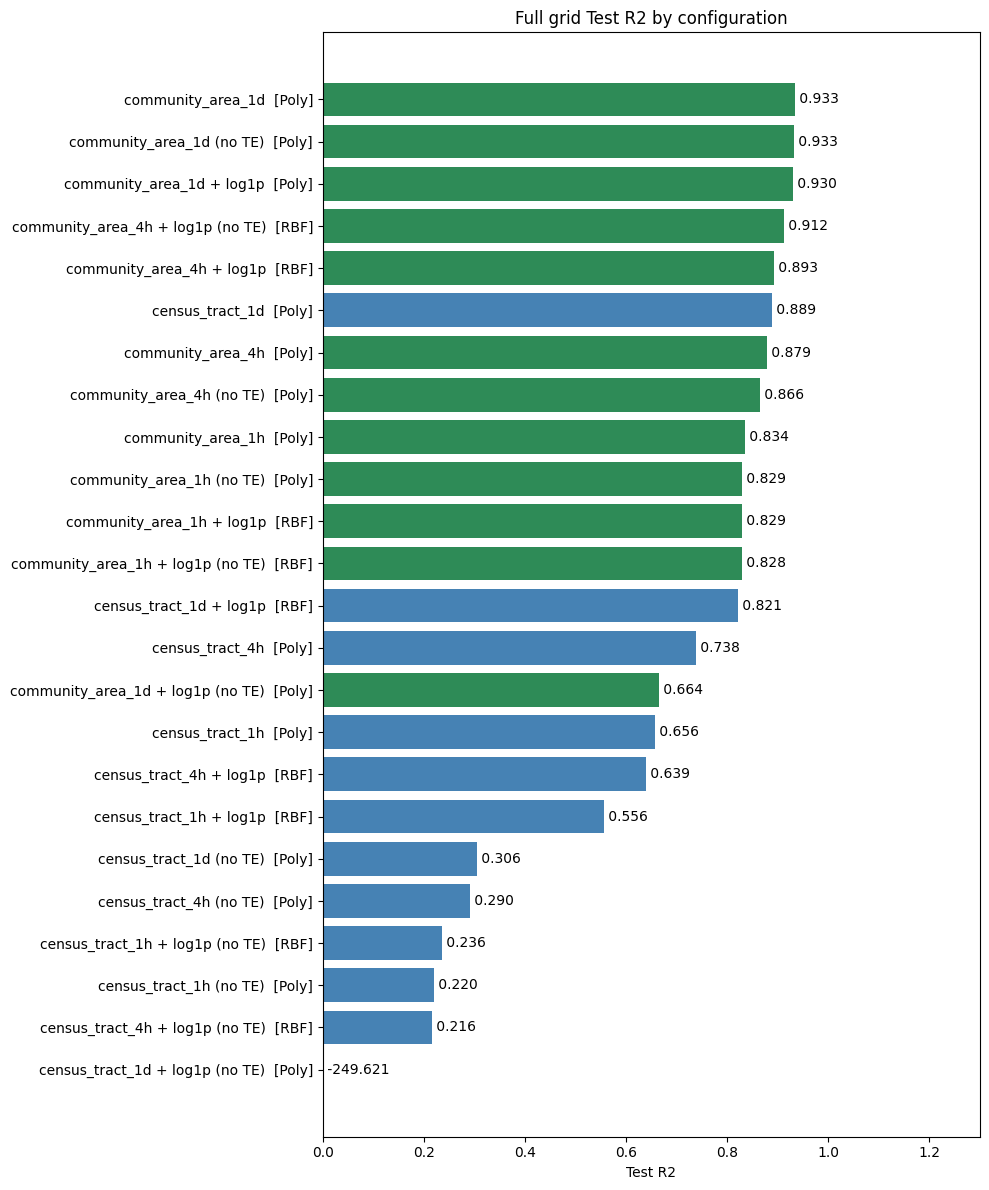

In [73]:
# all 24 configurations at a glance, sorted by test R2
sorted_tags = sorted(grid_results, key=lambda k: grid_results[k]["test_r2"])
bar_labels = [f"{t}  [{grid_results[t]['best_model']}]" for t in sorted_tags]
r2_vals = [grid_results[t]["test_r2"] for t in sorted_tags]
colors  = [SPATIAL_COLORS[grid_results[t]["spatial"]] for t in sorted_tags]

fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(bar_labels, r2_vals, color=colors)

for bar, v in zip(bars, r2_vals):
    # Prevent text clipping for extreme negative R2 outliers
    ax.text(max(0, bar.get_width()), bar.get_y() + bar.get_height()/2,
            f" {v:.3f}", va="center")

ax.set_xlabel("Test R2")
ax.set_xlim(0,1.3)  # clip at -1; extreme outliers are still labelled with their value
ax.set_title("Full grid Test R2 by configuration")
plt.tight_layout()
plt.show()


Comparison of MAE and rMAE

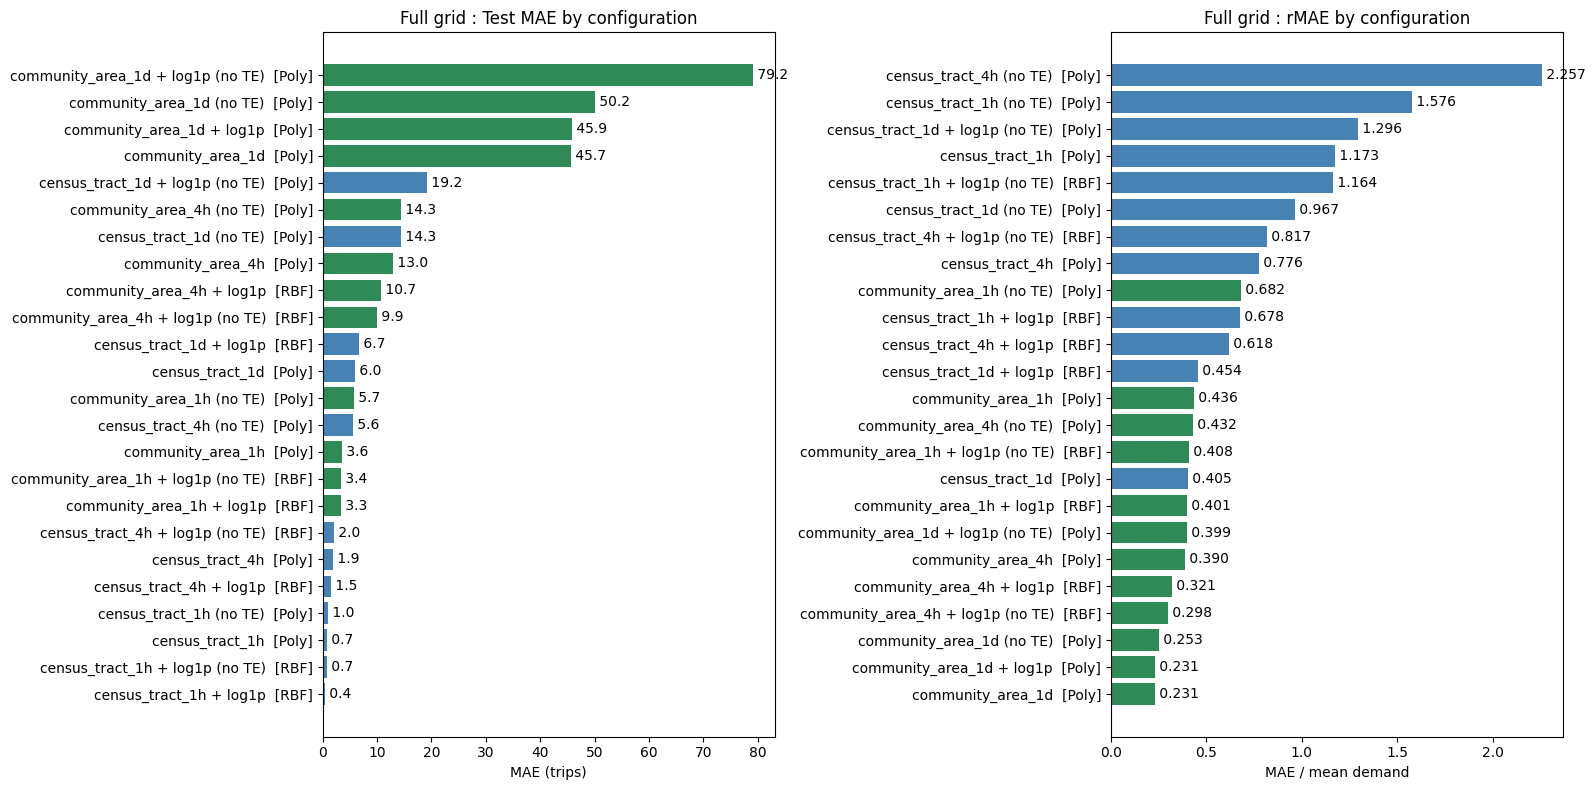

In [61]:
# raw MAE is scale-dependent (1d windows hold ~24x more trips than 1h),
# rMAE divides by each config's mean demand to compare across scales
tags_mae = sorted(grid_results, key=lambda k: grid_results[k]["test_mae"])
labels_mae = [f"{t}  [{grid_results[t]['best_model']}]" for t in tags_mae]
vals_mae = [grid_results[t]["test_mae"] for t in tags_mae]
colors_mae = [SPATIAL_COLORS[grid_results[t]["spatial"]] for t in tags_mae]

tags_nmae = sorted(grid_results, key=lambda k: grid_results[k]["test_mae"] / grid_results[k]["y_test"].mean())
labels_nmae = [f"{t}  [{grid_results[t]['best_model']}]" for t in tags_nmae]
vals_nmae = [grid_results[t]["test_mae"] / grid_results[t]["y_test"].mean() for t in tags_nmae]
colors_nmae = [SPATIAL_COLORS[grid_results[t]["spatial"]] for t in tags_nmae]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
bars = axes[0].barh(labels_mae, vals_mae, color=colors_mae)
for bar, v in zip(bars, vals_mae):
    axes[0].text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                 f" {v:.1f}", va="center")
axes[0].set_xlabel("MAE (trips)")
axes[0].set_title("Full grid : Test MAE by configuration")
bars = axes[1].barh(labels_nmae, vals_nmae, color=colors_nmae)
for bar, v in zip(bars, vals_nmae):
    axes[1].text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                 f" {v:.3f}", va="center")
axes[1].set_xlabel("MAE / mean demand")
axes[1].set_title("Full grid : rMAE by configuration")
plt.tight_layout(); plt.show()


# 10) Kernel comparison
Validation RMSE of the three kernel families shows how performance improves as the model becomes more complex


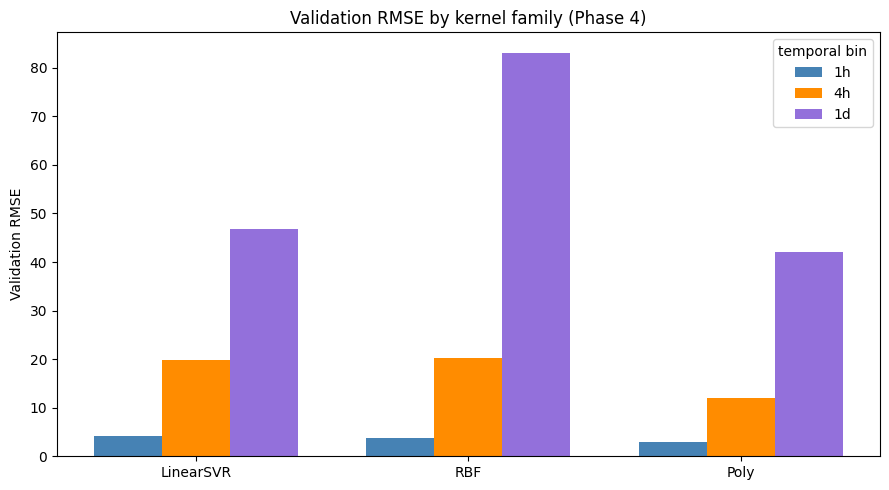

In [62]:
#| label: fig-svr-kernel-comparison
#| fig-cap: "Validation RMSE by kernel family across all configurations."
families = ["LinearSVR", "RBF", "Poly"]
x = np.arange(len(families))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
for i, b in enumerate(["1h", "4h", "1d"]):
    vals = [phase_temporal[b]["all_val_rmse"].get(f, np.nan) for f in families]
    ax.bar(x + i * width, vals, width, label=b, color=BIN_COLORS[b])
ax.set_xticks(x + width); ax.set_xticklabels(families)
ax.set_ylabel("Validation RMSE"); ax.set_title("Validation RMSE by kernel family (Phase 4)")
ax.legend(title="temporal bin")
plt.tight_layout(); plt.show()


# 11) Shortfalls & improvement levers

**Model performance & shortfalls**
- *Right-skewed target*: trip_count has a long right tail, so the squared-error objective is dominated by a few high-demand baskets. The log1p transform (Phase 3) helps stabilise the variance but can reduce R² on the original scale because it under-predicts extreme peaks.
- *Sparse spatial units*: many census tracts contain only a handful of trips per basket, making per-unit predictions noisy. This is why the coarser community area layer generally fits better (more trips per unit, less noise).
- *Resolution trade-off*: finer temporal bins (1 h) give more detail but also more noise and sparser baskets. Coarser bins (4 h, 1 d) aggregate demand and are easier to predict (higher R², lower MAPE) but lose intra-day structure.
- *SVR scaling limitation*: kernel SVR (RBF/Poly) scales ~O(n²), so grid search fits on a 20 k-row subsample and the final refit on 50 k rows because of computational power. The full training set (300 k–600 k rows) is intractable for non-linear SVR.
- *Missing exogenous regressors*: large events, school holidays and airport flight schedules are not represented. We tried to include them but didn't have proper and reliable data for it.


**Improvement levers for a follow-up project**
- *Stronger models*: gradient-boosted trees (LightGBM / XGBoost) handle non-linearities, large *n* and feature interactions far more efficiently than kernel SVR.
- *Calibrated probabilistic forecasts*: predict demand distributions (quantiles) rather than point estimates.
- *Realised trips vs actual demand*: the dataset only records trips which were taken but not the actual demand. So trips which were needed but never taken are not included. This is a limitation of the dataset rather than a model but could have a huge impact on the truth of the demand. For a fleet operator to act on realized trips in the past could reinforce existing gaps


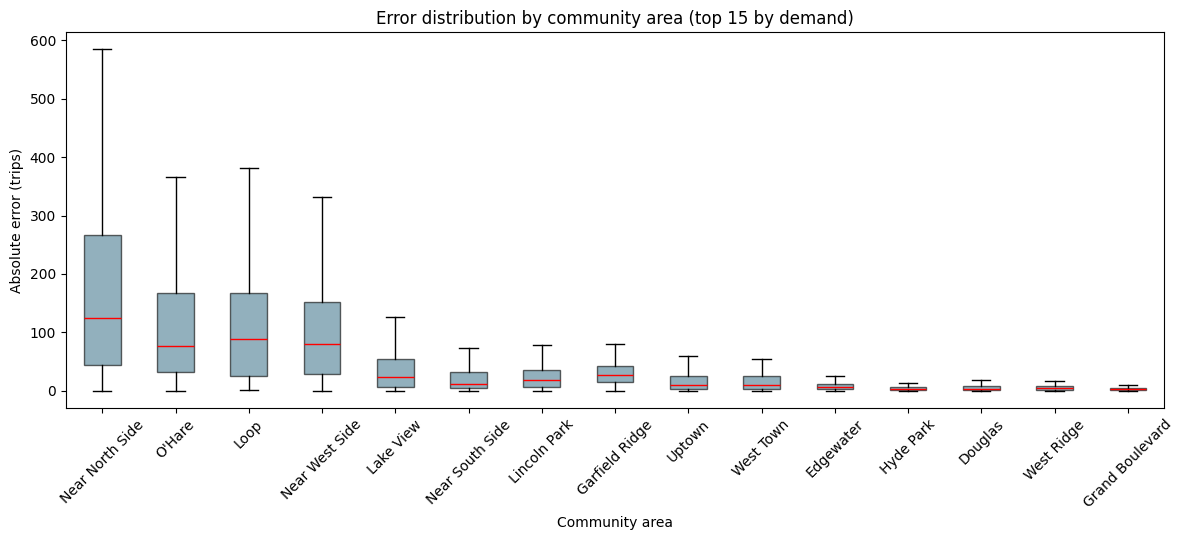

In [63]:
#| label: fig-svr-error-boxplot
#| fig-cap: "Absolute error distribution by community area (top 15 by demand) for the recommended configuration (community area, 4h, log1p, RBF)."

CA_NAMES = {
    8: "Near North Side", 76: "O'Hare", 32: "Loop",
    28: "Near West Side", 6: "Lake View", 33: "Near South Side",
    7: "Lincoln Park", 56: "Garfield Ridge", 3: "Uptown",
    24: "West Town", 77: "Edgewater", 41: "Hyde Park",
    35: "Douglas", 2: "West Ridge", 38: "Grand Boulevard"
}

res = grid_results["community_area_4h + log1p"]
pred_ca = ca_4h_test.select(["community_area"]).with_columns([
    pl.Series("actual", res["y_test"]),
    pl.Series("predicted", res["y_pred"]),
    pl.Series("abs_error", np.abs(res["y_test"] - res["y_pred"])),
])

top_cas = (pred_ca.group_by("community_area")
           .agg(pl.col("actual").mean())
           .sort("actual", descending=True)
           .head(15)["community_area"].to_list())

top_labels = [CA_NAMES.get(ca, str(ca)) for ca in top_cas]

groups = [pred_ca.filter(pl.col("community_area") == ca)["abs_error"].to_numpy()
          for ca in top_cas]

fig, ax = plt.subplots(figsize=(12, 5.5))
bp = ax.boxplot(groups, tick_labels=top_labels, patch_artist=True,
                boxprops=dict(facecolor="#4a7c91", alpha=0.6),
                medianprops=dict(color="red"), showfliers=False)
ax.set_xlabel("Community area")
ax.set_ylabel("Absolute error (trips)")
ax.set_title("Error distribution by community area (top 15 by demand)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

## Example predictions by spatial unit


In [64]:
# attach predictions of the recommended config back to their spatial units
# reuse pred_ca from the error-boxplot cell above
pred_table = pred_ca.select(["community_area", "actual",
                             pl.col("predicted").round(1)])
print("Sample rows:")
display(pred_table.head(5))
print("Top 10 spatial units by predicted demand:")
display(pred_table.group_by("community_area")
        .agg(pl.col("predicted").mean().round(1))
        .sort("predicted", descending=True).head(10))

Sample rows:


community_area,actual,predicted
i64,f64,f64
75,3.0,6.1
76,144.0,191.4
77,41.0,32.1
1,22.0,24.4
2,28.0,25.9


Top 10 spatial units by predicted demand:


community_area,predicted
i64,f64
76,522.4
8,489.3
32,351.9
28,221.9
56,74.2
33,69.0
6,66.8
7,44.3
3,35.7


# 12) Business comparison - SVR vs. fleet-operator baseline

A fleet operator without a model would plan from a simple rule of thumb: *"In community area X, during the 8-12 basket, average demand is Y trips."* This is the **historical mean** of `trip_count` per **(community area x 4 h basket x weekday/weekend)**, learned on the training set and applied to the test set (the operator can tell a weekday from a Saturday, but not a Monday from a Wednesday). The cell below compares that baseline against the recommended SVR configuration (`community_area_4h + log1p`, RBF) using **normalized MAE** and **R2**, and reports by how many percent the model beats the rule of thumb.

In [65]:
# recover the 4h-basket start hour (0,4,8,12,16,20) and a weekend flag
def _basket_hour(df):
    ang = np.degrees(np.arctan2(df["hour_sin"].to_numpy(), df["hour_cos"].to_numpy())) % 360
    return np.round(ang / 15).astype(int) % 24

def _is_weekend(df):
    return ((df["DayOfWeek_Saturday"] == 1) | (df["DayOfWeek_Sunday"] == 1)).to_numpy()

# baseline: mean trip_count per (community_area x basket_hour x weekend) on TRAIN
train_view = ca_4h_train.with_columns([
    pl.Series("basket_hour", _basket_hour(ca_4h_train)),
    pl.Series("is_weekend", _is_weekend(ca_4h_train)),
])
baseline_lookup = (train_view
    .group_by(["community_area", "basket_hour", "is_weekend"])
    .agg(pl.col("trip_count").mean().alias("baseline_pred")))

# apply the baseline to the TEST rows (same row order as grid_results y_pred)
test_view = (ca_4h_test
    .with_columns([
        pl.Series("basket_hour", _basket_hour(ca_4h_test)),
        pl.Series("is_weekend", _is_weekend(ca_4h_test)),
    ])
    .join(baseline_lookup, on=["community_area", "basket_hour", "is_weekend"], how="left", maintain_order="left")
    # unseen (area x basket x weekend) combos fall back to the global training mean
    .with_columns(pl.col("baseline_pred").fill_null(ca_4h_train["trip_count"].mean())))

y_true     = grid_results["community_area_4h + log1p"]["y_test"]
y_svr      = grid_results["community_area_4h + log1p"]["y_pred"]
y_baseline = test_view["baseline_pred"].to_numpy()

def _rmae(yt, yp):
    return np.mean(np.abs(yt - yp)) / np.mean(yt)

summary = pl.DataFrame([
    {"Approach": "Fleet-operator baseline", "RMAE": _rmae(y_true, y_baseline), "R2": r2_score(y_true, y_baseline)},
    {"Approach": "SVR model",               "RMAE": _rmae(y_true, y_svr),      "R2": r2_score(y_true, y_svr)},
]).with_columns([pl.col("RMAE").round(4), pl.col("R2").round(4)])
display(summary)

gain = (_rmae(y_true, y_baseline) - _rmae(y_true, y_svr)) / _rmae(y_true, y_baseline) * 100
print(f"\n>> The SVR model's RMAE is {gain:.1f}% lower than the fleet-operator rule of thumb.")

# concrete example: Loop (CA 32), 8-12 basket
ex = baseline_lookup.filter((pl.col("community_area") == 32) & (pl.col("basket_hour") == 8)).sort("is_weekend")
print("Loop (CA 32), 8-12 basket, baseline average demand:")
for r in ex.iter_rows(named=True):
    flag = "weekend" if r["is_weekend"] else "weekday"
    print(f"  {flag}: {r['baseline_pred']:.1f} trips")

Approach,RMAE,R2
str,f64,f64
"""Fleet-operator baseline""",0.3101,0.9041
"""SVR model""",0.3207,0.8929



>> The SVR model's RMAE is -3.4% lower than the fleet-operator rule of thumb.
Loop (CA 32), 8-12 basket, baseline average demand:
  weekday: 665.6 trips
  weekend: 333.1 trips


Example Rule of Thumb number for the Fleet operator who does not use a model

In [66]:
ang = np.degrees(np.arctan2(
    ca_4h_train["hour_sin"].to_numpy(),
    ca_4h_train["hour_cos"].to_numpy()
)) % 360
basket_hour = np.round(ang / 15).astype(int) % 24

result = ca_4h_train.with_columns([
    pl.Series("basket_hour", basket_hour)
]).filter(
    (pl.col("community_area") == 10) &
    (pl.col("basket_hour") == 8) &
    (pl.col("DayOfWeek_Tuesday") == 1)
)

print(f"Fleet operator baseline calculation on a tuesday between 8:00-12:00 in Community Area 10 (train avg): {result['trip_count'].mean():.1f} trips")

Fleet operator baseline calculation on a tuesday between 8:00-12:00 in Community Area 10 (train avg): 8.2 trips
